# **Loading Quantum Error Correcting Code (QECCs) Matrices from HDF5**

This notebook demonstrates how to load **parity-check** and **logical-operator** matrices for CSS quantum error-correcting codes (QECCs) that were saved from **Julia** in HDF5 format.

### *Why do we need to transpose*?

Julia stores arrays in **column-major** order (like Fortran, MATLAB),
while NumPy/Python uses **row-major** order (like C).
When an HDF5 file written by Julia is read by Python's h5py, the axes are swapped.

```
Julia matrix  shape  (m, n)   →   h5py reads it as  (n, m)
```

So after reading we call `.T` (transpose) to restore the original logical shape.

> **Further reading on column-major vs row-major in HDF5**
> - [Read HDF5 data with numpy axis order with Julia HDF5 (Stack Overflow)](https://stackoverflow.com/questions/31393372/read-hdf5-data-with-numpy-axis-order-with-julia-hdf5)
> - [Why column-major? (Julia Discourse)](https://discourse.julialang.org/t/why-column-major/24374)
> - [Why does MATLAB transpose HDF5 data? (MathWorks)](https://www.mathworks.com/matlabcentral/answers/308303-why-does-matlab-transpose-hdf5-data)

For the logical operators there is an additional detail:
Julia (using `QuantumClifford.jl`) packs both Lx and Lz into a single `(2n, k)` matrix
(rows `0..n-1` (`1..n` in Julia) = X logicals, rows `n..2n-1` (`n..2n` in Julia) = Z logicals).
After h5py reads it as `(k, 2n)` we slice the relevant columns *before* transposing.

## **Mount Google Drive & imports**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path
import h5py
import numpy as np
import scipy.sparse as sparse

## **QECCs**

Each entry maps a short code name to
`(hdf5_filename, n, k, d)`.

In [3]:
CODE_PARAMS = {
    "AMC_156_6_10":       ("amc_resultsnew1000_l26_16_19_22_25.h5",           156,    6,  10),
    # Add codes here
}

## **Loader function**

### HDF5 dataset layout (as written by Julia)

| Dataset key | Julia shape | h5py shape | After `.T` |
|---|---|---|---|
| `parity_matrix_x` | `(m_x, n)` | `(n, m_x)` | `(m_x, n)` ✓ |
| `parity_matrix_z` | `(m_z, n)` | `(n, m_z)` | `(m_z, n)` ✓ |
| `logx_ops` | `(k, 2n)` | `(2n, k)` | `[:n, :].T` → `(k, n)` — Pauli X-type rows only |
| `logz_ops` | `(k, 2n)` | `(2n, k)` | `[n:, :].T` → `(k, n)` — Pauli Z-type rows only |

In [4]:
def load_code_matrices(code_name: str, data_path: str | Path):
    if code_name not in CODE_PARAMS:
        raise ValueError(
            f"Unknown code: {code_name!r}. "
            f"Available: {list(CODE_PARAMS.keys())}"
        )
    filename, n, k, d = CODE_PARAMS[code_name]
    filepath = Path(data_path) / filename
    if not filepath.exists():
        raise FileNotFoundError(f"Code file not found: {filepath}")
    with h5py.File(filepath, "r") as f:
        Hx_raw = np.array(f["parity_matrix_x"][()], dtype=np.uint8) % 2
        Hz_raw = np.array(f["parity_matrix_z"][()], dtype=np.uint8) % 2
        Lx_raw = np.array(f["logx_ops"][()],        dtype=np.uint8) % 2
        Lz_raw = np.array(f["logz_ops"][()],        dtype=np.uint8) % 2
        print("Hx raw:", Hx_raw.shape)
        print("Hz raw:", Hz_raw.shape)
        print("Lx raw:", Lx_raw.shape)
        print("Lz raw:", Lz_raw.shape)
    Hx = sparse.csr_matrix(Hx_raw.T)
    Hz = sparse.csr_matrix(Hz_raw.T)
    Lx = sparse.csr_matrix(Lx_raw[:n, :].T)
    Lz = sparse.csr_matrix(Lz_raw[n:, :].T)

    return Hx, Hz, Lx, Lz, n, k, d

## **Load a code and inspect the shapes**

In [5]:
DATA_PATH = Path("/content/drive/MyDrive/AMC (table VI)")
CODE      = "AMC_156_6_10"

Hx, Hz, Lx, Lz, n, k, d = load_code_matrices(CODE, DATA_PATH)

print(f"Code     : [[{n}, {k}, {d}]]")
print(f"Hx shape : {Hx.shape}   (m_x stabilisers × {n} qubits)")
print(f"Hz shape : {Hz.shape}   (m_z stabilisers × {n} qubits)")
print(f"Lx shape : {Lx.shape}   ({n} qubits × {k} X-logicals)")
print(f"Lz shape : {Lz.shape}   ({n} qubits × {k} Z-logicals)")

Hx raw: (156, 104)
Hz raw: (156, 104)
Lx raw: (312, 6)
Lz raw: (312, 6)
Code     : [[156, 6, 10]]
Hx shape : (104, 156)   (m_x stabilisers × 156 qubits)
Hz shape : (104, 156)   (m_z stabilisers × 156 qubits)
Lx shape : (6, 156)   (156 qubits × 6 X-logicals)
Lz shape : (6, 156)   (156 qubits × 6 Z-logicals)


## **Sanity checks for a CSS code**

|  |  |
|---|---|
| `Hx @ Hz.T = 0` | Pauli X- and Pauli Z-stabilisers generators commute |
| `Hx @ Lz = 0`   | Pauli X-stabilisers generators commute with Pauli Z-logicals |
| `Hz @ Lx = 0`   | Pauli Z-stabilisers generators commute with Pauli X-logicals |


In [6]:
import numpy as np
from itertools import combinations

def check_css_conditions(Hx, Hz, Lx, Lz):
    HxHz = (Hx @ Hz.T).toarray() % 2
    HxLz = (Hx @ Lz.T).toarray() % 2
    HzLx = (Hz @ Lx.T).toarray() % 2
    results = {
        "Hx · Hz^T = 0": np.all(HxHz == 0),
        "Hx · Lz^T = 0": np.all(HxLz == 0),
        "Hz · Lx^T = 0": np.all(HzLx == 0),
    }
    all_ok = all(results.values())
    for label, ok in results.items():
        status = "✓" if ok else "✗"
        print(f"{status} {label}")
    if not results["Hx · Hz^T = 0"]:
        print("\nHxHz mod 2:")
        print(HxHz)
    if not results["Hx · Lz^T = 0"]:
        print("\nHxLz mod 2:")
        print(HxLz)
    if not results["Hz · Lx^T = 0"]:
        print("\nHzLx mod 2:")
        print(HzLx)
    print("\nAll CSS conditions satisfied:", all_ok)

check_css_conditions(Hx, Hz, Lx, Lz)

✓ Hx · Hz^T = 0
✓ Hx · Lz^T = 0
✓ Hz · Lx^T = 0

All CSS conditions satisfied: True


# **Raw HDF5 walkthrough**


In [7]:
filepath = DATA_PATH / CODE_PARAMS[CODE][0]

with h5py.File(filepath, "r") as f:
    print(f"File: {filepath.name}")
    print(f"{'Dataset':<25} {'h5py shape (transposed)':<30} {'dtype'}")
    print("-" * 65)
    for key in f.keys():
        ds = f[key]
        print(f"{key:<25} {str(ds.shape):<30} {ds.dtype}")

File: amc_resultsnew1000_l26_16_19_22_25.h5
Dataset                   h5py shape (transposed)        dtype
-----------------------------------------------------------------
logx_ops                  (312, 6)                       uint8
logz_ops                  (312, 6)                       uint8
parity_matrix_x           (156, 104)                     int64
parity_matrix_z           (156, 104)                     int64


## **Peek at a matrix**


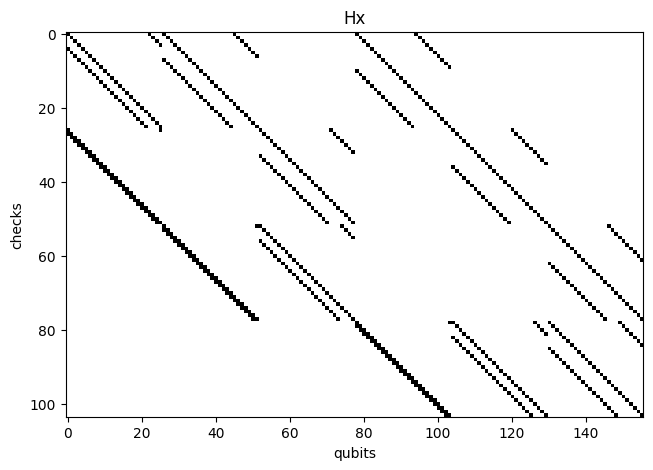

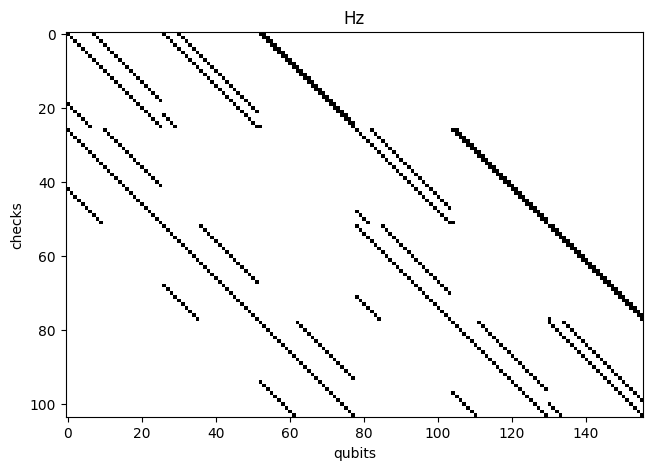

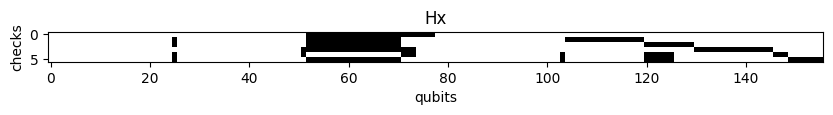

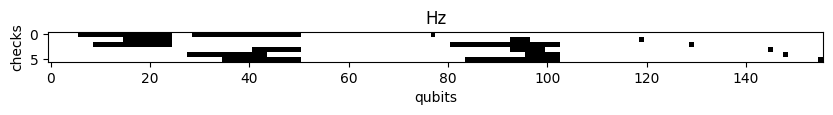

In [8]:
import matplotlib.pyplot as plt

def show_binary_matrix(A, title=""):
    A = A.toarray() if hasattr(A, "toarray") else A

    plt.figure(figsize=(10, 5))
    plt.imshow(A, cmap="gray_r", vmin=0, vmax=1, interpolation="none")
    plt.title(title)
    plt.xlabel("qubits")
    plt.ylabel("checks")
    plt.show()
show_binary_matrix(Hx, "Hx")
show_binary_matrix(Hz, "Hz")
show_binary_matrix(Lx, "Hx")
show_binary_matrix(Lz, "Hz")